In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.optimize import minimize
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.linalg import eigh
from sklearn.covariance import GraphicalLassoCV
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

try:
    from skopt import gp_minimize
    from skopt.space import Integer, Real
    print("Bayesian Optimization libraries (skopt) ready.")
except ImportError:
    print("Installing missing dependencies: scikit-optimize...")
    import subprocess
    import sys
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-optimize"])
        from skopt import gp_minimize
        from skopt.space import Integer, Real
        print("scikit-optimize installed and imported.")
    except:
        print("Could not install skopt. Bayesian strategies will fall back to static parameters.")

print("Libraries imported successfully!")

Bayesian Optimization libraries (skopt) ready.
Libraries imported successfully!


In [2]:
excel_file = 'crypto_data_real.xlsx'
df_returns = pd.read_excel(excel_file, sheet_name='Returns', index_col=0)
df_prices  = pd.read_excel(excel_file, sheet_name='Prices',  index_col=0)

crypto_names = df_returns.columns.tolist()
n_assets     = len(crypto_names)

print(f"Data loaded: {df_returns.shape[0]} days, {n_assets} assets")
print(f"Period: {df_returns.index[0]} to {df_returns.index[-1]}")

Data loaded: 763 days, 10 assets
Period: 2017-09-15 00:00:00 to 2019-10-17 00:00:00


In [3]:
summary_stats = pd.DataFrame({
    'Mean':     df_returns.mean(),
    'Std':      df_returns.std(),
    'Kurtosis': df_returns.kurt(),
    'Skewness': df_returns.skew()
})

print("TABLE 1 | Summary statistics.")
print(summary_stats.round(4))

TABLE 1 | Summary statistics.
        Mean     Std  Kurtosis  Skewness
BTC   0.0012  0.0434    3.0822    0.0523
ETH  -0.0008  0.0507    2.8209   -0.2916
XRP   0.0004  0.0654   18.9009    2.0588
USDT -0.0000  0.0057   21.7209    0.7437
BCH  -0.0014  0.0724    7.5671    0.6231
LTC   0.0004  0.0585    6.6357    1.0988
BNB   0.0029  0.0621   10.2612    1.0694
EOS   0.0012  0.0709    4.7582    0.5781
XLM   0.0006  0.0657    7.0332    0.9799
TRX   0.0025  0.0879   22.1856    2.6905


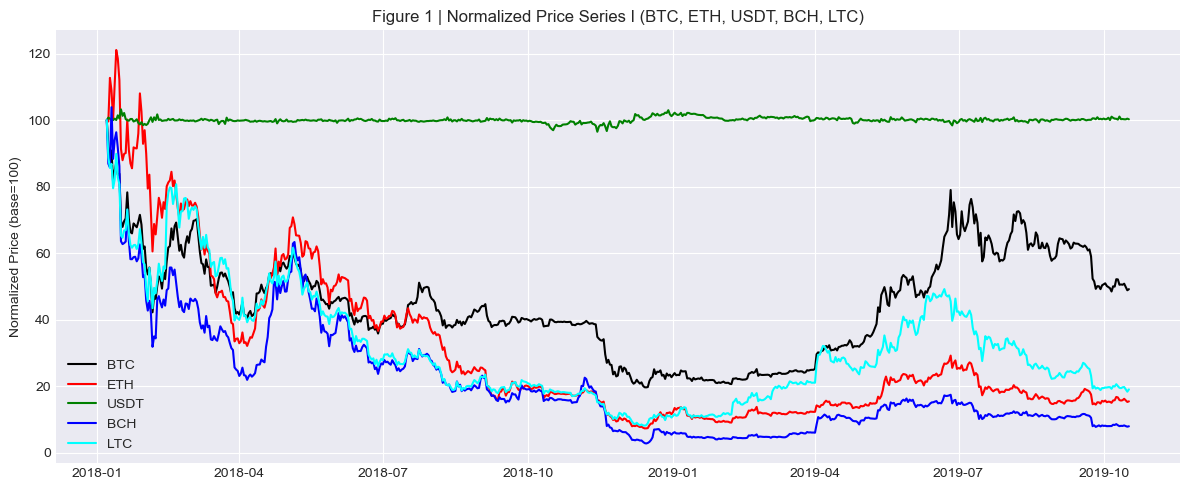

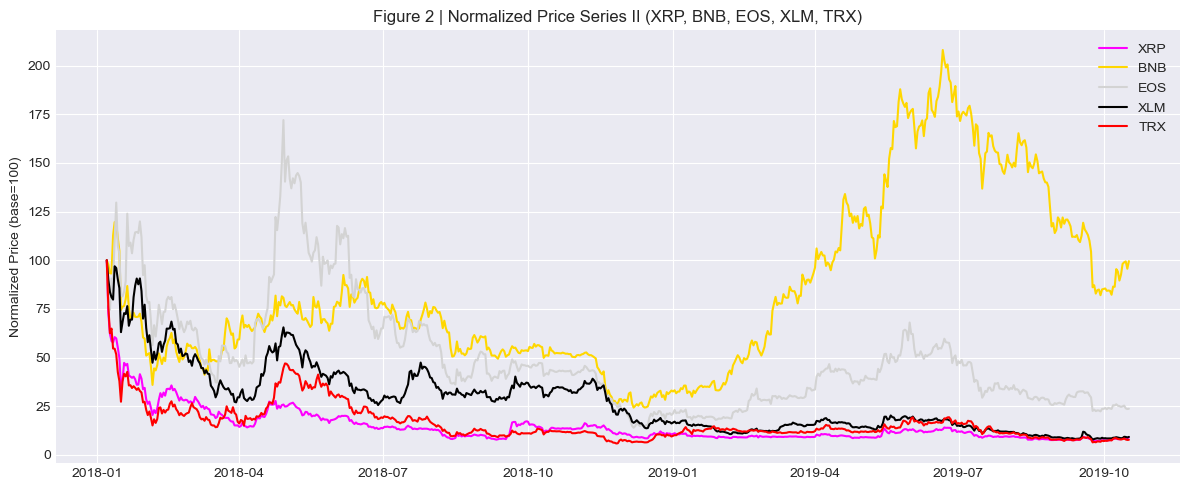

In [4]:
assets_1 = ['BTC', 'ETH', 'USDT', 'BCH', 'LTC']
df_norm_1 = (df_prices.loc['2018-01-07':, assets_1] /
             df_prices.loc['2018-01-07', assets_1]) * 100

colors_1 = ['black', 'red', 'green', 'blue', 'cyan']

plt.figure(figsize=(12, 5))
for i, col in enumerate(df_norm_1.columns):
    plt.plot(df_norm_1.index, df_norm_1[col],
             label=col, color=colors_1[i])
plt.title('Figure 1 | Normalized Price Series I (BTC, ETH, USDT, BCH, LTC)')
plt.ylabel('Normalized Price (base=100)')
plt.legend()
plt.tight_layout()
plt.show()

assets_2 = ['XRP', 'BNB', 'EOS', 'XLM', 'TRX']
df_norm_2 = (df_prices.loc['2018-01-07':, assets_2] /
             df_prices.loc['2018-01-07', assets_2]) * 100

colors_2 = ['magenta', 'gold', 'lightgrey', 'black', 'red']

plt.figure(figsize=(12, 5))
for i, col in enumerate(df_norm_2.columns):
    plt.plot(df_norm_2.index, df_norm_2[col],
             label=col, color=colors_2[i])
plt.title('Figure 2 | Normalized Price Series II (XRP, BNB, EOS, XLM, TRX)')
plt.ylabel('Normalized Price (base=100)')
plt.legend()
plt.tight_layout()
plt.show()

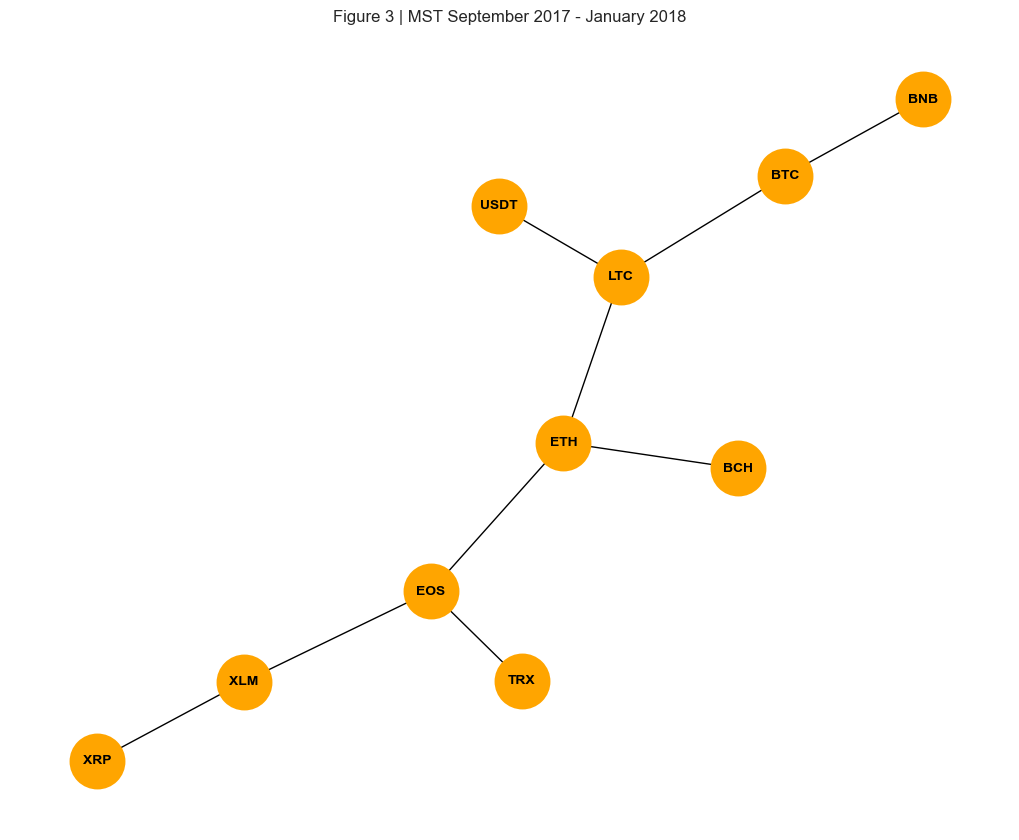

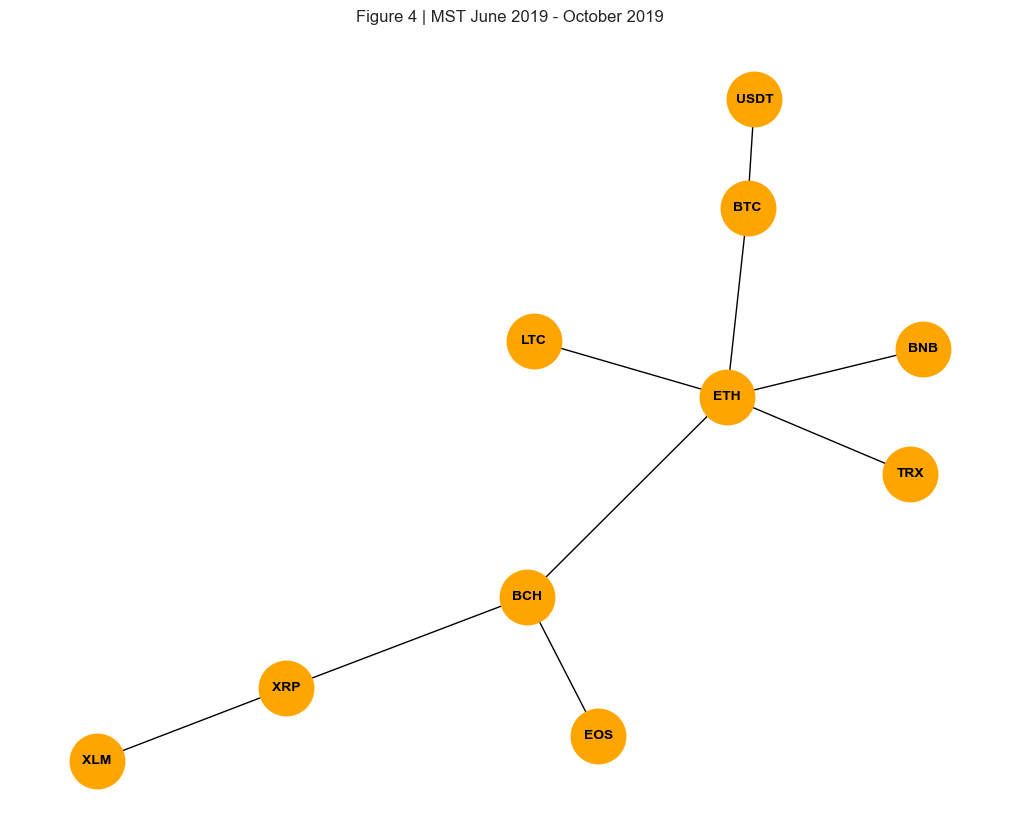

In [5]:
df_bubble   = df_returns.loc['2017-09-14':'2018-01-31']
corr_bubble = df_bubble.corr()
dist_bubble = np.sqrt(2 * (1 - corr_bubble))

G          = nx.from_pandas_adjacency(dist_bubble)
mst_bubble = nx.minimum_spanning_tree(G, weight='weight')

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(mst_bubble, seed=42)
nx.draw(mst_bubble, pos, with_labels=True, node_color='orange',
        node_size=1500, edge_color='black', linewidths=1.5,
        font_size=10, font_weight='bold')
plt.title('Figure 3 | MST September 2017 - January 2018', fontsize=12)
plt.show()

df_stable   = df_returns.loc['2019-06-01':'2019-10-17']
corr_stable = df_stable.corr()
dist_stable = np.sqrt(2 * (1 - corr_stable))

G2         = nx.from_pandas_adjacency(dist_stable)
mst_stable = nx.minimum_spanning_tree(G2, weight='weight')

plt.figure(figsize=(10, 8))
pos2 = nx.spring_layout(mst_stable, seed=42)
nx.draw(mst_stable, pos2, with_labels=True, node_color='orange',
        node_size=1500, edge_color='black', linewidths=1.5,
        font_size=10, font_weight='bold')
plt.title('Figure 4 | MST June 2019 - October 2019', fontsize=12)
plt.show()

In [6]:
def apply_rmt_filter(returns_data):
    """
    Menerapkan filter Random Matrix Theory (RMT) pada matriks korelasi aset.
    
    Fungsi ini bertujuan untuk memisahkan "sinyal" (informasi pasar yang sebenarnya) 
    dari "noise" (fluktuasi acak) dalam matriks korelasi imbal hasil (returns) aset. 
    Metode ini sangat berguna dalam optimasi portofolio untuk mencegah terjadinya over-fitting 
    terhadap noise historis, sehingga estimasi matriks korelasi yang dihasilkan menjadi 
    lebih stabil dan dapat diandalkan (robust).

    Alur Narasi Proses:
    1. Persiapan Data: Memastikan data berformat matriks numpy agar siap diolah.
    2. Korelasi Empiris: Membentuk matriks korelasi Pearson standar dari data imbal hasil.
    3. Dekomposisi Eigen: Memecah matriks korelasi menjadi nilai eigen dan vektor eigen untuk 
       melihat varians dari komponen utama.
    4. Thresholding Marchenko-Pastur: Menghitung ambang batas (lambda_plus) acak 
       berdasarkan teori matriks acak.
    5. Penyaringan (Filtering): Memilah mana nilai eigen yang "nyata" (sinyal) 
       dan mana yang "acak" (noise). Noise kemudian dihilangkan (di-nol-kan).
    6. Rekonstruksi: Membangun kembali matriks korelasi baru yang sudah dibersihkan dari noise.

    Parameters:
    -----------
    returns_data : pandas.DataFrame atau numpy.ndarray
        Data deret waktu imbal hasil (returns) dari berbagai aset. 
        Asumsi format: Baris (T observasi) x Kolom (N aset).

    Returns:
    --------
    C_filtered : numpy.ndarray
        Matriks korelasi baru (N x N) yang telah disaring dan dibersihkan dari noise.
    """
    
    if isinstance(returns_data, pd.DataFrame):
        data = returns_data.values
    else:
        data = returns_data
        
    T, N = data.shape
    
    Q = T / N
    
    C = np.corrcoef(data.T)

    eigenvalues, eigenvectors = eigh(C)
    
    eigenvalues  = eigenvalues[::-1]
    eigenvectors = eigenvectors[:, ::-1]

    lambda_plus = 1 + (1/Q) + 2*np.sqrt(1/Q)
    
    significant_mask = eigenvalues > lambda_plus

    Lambda_filtered = np.diag(np.where(significant_mask, eigenvalues, 0))
    
    C_filtered = eigenvectors @ Lambda_filtered @ eigenvectors.T
    
    return C_filtered

def build_mst(correlation_matrix):
    """
    Menghitung matriks jarak (Distance Matrix) dari matriks korelasi sebagai
    tahap pra-pemrosesan untuk pembentukan Minimum Spanning Tree (MST).
    
    Transformasi ini menggunakan metrik jarak Mantegna (1999) yang secara
    umum didefinisikan sebagai d_ij = sqrt(2 * (1 - rho_ij)). Metrik ini
    mentransformasikan korelasi (Pearson) ke dalam ruang Euclidean.
    
    Matematika Transformasi:
    1. Jika rho =  1 (Korelasi Positif Sempurna), maka d = 0 (Jarak terdekat).
    2. Jika rho =  0 (Tidak Ada Korelasi),       maka d = sqrt(2) ≈ 1.41.
    3. Jika rho = -1 (Korelasi Negatif Sempurna), maka d = 2 (Jarak terjauh).
    
    Parameters:
    -----------
    correlation_matrix : numpy.ndarray
        Matriks korelasi antar aset berukuran (N x N). Matriks ini harus
        bersifat simetris dan memiliki nilai diagonal bernilai 1.0.
        
    Returns:
    --------
    distance_matrix : numpy.ndarray
        Matriks jarak berukuran (N x N) yang memenuhi sifat-sifat metrik:
        - Non-negatif: d_ij >= 0
        - Identitas: d_ii = 0
        - Simetris: d_ij = d_ji
        - Ketidaksamaan Segitiga: d_ij <= d_ik + d_kj
    """
    
    distance_matrix = np.sqrt(2 - 2 * correlation_matrix)
    
    np.fill_diagonal(distance_matrix, 0)
    
    return distance_matrix

def compute_eigenvector_centrality(distance_matrix):
    """
    Menghitung skor Eigenvector Centrality dari matriks jarak (Distance Matrix).
    
    Eigenvector centrality memberikan ukuran seberapa 'penting' suatu aset 
    di dalam jaringan. Berbeda dengan degree centrality (yang hanya menghitung 
    jumlah koneksi), eigenvector centrality mempertimbangkan kualitas koneksi; 
    suatu aset dianggap penting jika ia terhubung dengan aset-aset lain yang 
    juga memiliki kepentingan tinggi.
    
    Dalam studi portofolio (Network Markowitz), metrik ini digunakan untuk 
    mendeteksi aset sistemik atau aset yang berada di pusat kluster risiko.
    Parameters:
    -----------
    distance_matrix : numpy.ndarray
        Matriks jarak berukuran (N x N). Nilai kecil pada matriks ini 
        menunjukkan korelasi yang kuat antar aset.
    Returns:
    --------
    centrality : numpy.ndarray
        Vektor berukuran (N,) berisi skor centrality yang dinormalisasi.
        Nilai yang lebih tinggi menunjukkan aset yang lebih sentral di pasar.
    """
    
    adjacency = 1 / (distance_matrix + 1e-8)
    
    np.fill_diagonal(adjacency, 0)
    
    eigenvalues, eigenvectors = eigh(adjacency)
    
    principal_eigenvector = np.abs(eigenvectors[:, -1])
    
    centrality = principal_eigenvector / principal_eigenvector.sum()
    
    return centrality

def calculate_var(returns, confidence=0.95):
    """
    Menghitung Value at Risk (VaR) menggunakan metode Simulasi Historis.
    
    Value at Risk (VaR) adalah metrik risiko statistik yang mengestimasi 
    potensi kerugian maksimum dalam portofolio pada tingkat kepercayaan 
    tertentu dalam periode waktu tertentu.
    
    Contoh Interpretasi:
    Jika VaR(95%) bernilai -0.02, artinya kita memiliki keyakinan 95% bahwa 
    kerugian portofolio tidak akan melebihi 2% dalam satu hari kerja, 
    atau terdapat peluang 5% bahwa kerugian akan melampaul 2%.

    Parameters:
    -----------
    returns : numpy.ndarray | pandas.Series
        Data historis imbal hasil (return) dari aset atau portofolio.
    confidence : float, default 0.95
        Tingkat kepercayaan (confidence level). 0.95 berarti kita fokus 
        pada 5% kemungkinan terburuk (significance level alpha = 0.05).

    Returns:
    --------
    var_value : float
        Nilai batas bawah (threshold) imbal hasil pada persentil yang ditentukan.
    """
    
    alpha = 1 - confidence
    
    var_value = np.percentile(returns, alpha * 100)
    
    return var_value

def calculate_rachev_ratio(returns, alpha=0.10):
    """
    Menghitung Rachev Ratio untuk mengukur efisiensi imbal hasil pada ekor distribusi.
    
    Rachev Ratio mengukur perbandingan antara potensi keuntungan ekstrem (reward) 
    terhadap potensi kerugian ekstrem (risk). Berbeda dengan Sharpe Ratio, 
    metrik ini sangat efektif untuk aset dengan distribusi non-normal (fat-tails) 
    dan asimetris (skewed), yang umum ditemukan di pasar cryptocurrency.

    Formula:
    Rachev Ratio = CVaR(alpha, upper) / CVaR(alpha, lower)

    Interpretasi:
    Nilai > 1 menunjukkan bahwa potensi keuntungan di ekor kanan distribusi 
    lebih besar dibandingkan potensi kerugian di ekor kiri pada tingkat kepercayaan 1-alpha.

    Parameters:
    -----------
    returns : numpy.ndarray | pandas.Series
        Data historis imbal hasil (returns) strategi.
    alpha : float, default 0.10
        Tingkat signifikansi (probability tail). Misal 0.10 berarti kita 
        menganalisis 10% kejadian paling ekstrem (terbaik vs terburuk).

    Returns:
    --------
    rachev_ratio : float
        Rasio antara CVaR Atas per CVaR Bawah.
    """
    
    threshold_upper = np.percentile(returns, (1 - alpha) * 100)
    threshold_lower = np.percentile(returns, alpha * 100)
    
    cvar_upper = returns[returns >= threshold_upper].mean()
    
    cvar_lower = abs(returns[returns <= threshold_lower].mean())
    
    if cvar_lower > 0:
        rachev_ratio = cvar_upper / cvar_lower
    else:
        rachev_ratio = 0
        
    return rachev_ratio

def calculate_max_drawdown(cumulative_returns):
    """
    Menghitung Maximum Drawdown (MDD) dari deret imbal hasil kumulatif.
    
    Maximum Drawdown mengukur penurunan persentase terbesar yang diamati dari 
    titik puncak (peak) ke titik terendah (trough) dalam suatu periode waktu, 
    sebelum titik puncak baru terbentuk. Ini mencerminkan risiko kerugian 
    ekstrem yang mungkin dialami investor.

    Interpretasi:
    - Jika MDD = -0.25, berarti strategi tersebut pernah mengalami penurunan 
      nilai sebesar 25% dari titik tertingginya.
    - Semakin mendekati 0, semakin baik ketahanan strategi dalam menjaga modal.

    Parameters:
    -----------
    cumulative_returns : numpy.ndarray | pandas.Series
        Deret imbal hasil kumulatif (kurva ekuitas). 
        Pastikan input adalah data kumulatif (misal: 1, 1.05, 1.02, 1.08).

    Returns:
    --------
    max_drawdown : float
        Nilai penurunan maksimum dalam bentuk desimal (selalu <= 0).
    """

    running_max = np.maximum.accumulate(cumulative_returns)
    
    drawdown = (cumulative_returns - running_max) / running_max
    
    max_drawdown = drawdown.min()

    return max_drawdown

def get_assets_graph_diversify(returns_window, corr_threshold=0.4):
    """
    Melakukan seleksi aset untuk diversifikasi menggunakan algoritma 
    Maximum Independent Set (MIS) berbasis teori jaringan.
    
    Konsep Dasar Jaringan:
    1. Node (Simpul): Mewakili aset kripto dalam semesta portofolio.
    2. Edge (Sisi): Menghubungkan dua aset jika korelasi absolutnya melampaui 
       batas 'corr_threshold'. Sisi ini melambangkan 'redundansi' informasi risiko.
    3. Independent Set: Kumpulan aset yang TIDAK saling terhubung satu sama lain.
       Artinya, tidak ada aset dalam set ini yang memiliki korelasi tinggi.
    
    Tujuan Utama:
    Menemukan jumlah aset terbanyak yang memiliki tingkat ketergantungan (korelasi) 
    paling rendah satu sama lain demi memaksimalkan efek diversifikasi.
    Parameters:
    -----------
    returns_window : pandas.DataFrame
        Window data historis return aset (T bare x N kolom).
    corr_threshold : float, default 0.4
        Parameter theta (θ). Ambang batas di mana korelasi dianggap 'terlalu kuat'.
        Semakin rendah nilainya, semakin sedikit aset yang terpilih (diversifikasi sangat ketat).
    Returns:
    --------
    selected_assets : list
        Daftar nama aset terverifikasi yang membentuk Independent Set terbesar.
    """
    
    corr_mat = returns_window.corr()
    
    G = nx.Graph()
    
    assets = list(returns_window.mean()
                    .sort_values(ascending=False).index)
    
    G.add_nodes_from(assets)
    
    for i, a1 in enumerate(assets):
        for a2 in assets[i+1:]:
            if abs(corr_mat.loc[a1, a2]) > corr_threshold:
                G.add_edge(a1, a2)
    
    selected_assets = list(nx.approximation.maximum_independent_set(G))
    
    return selected_assets

def get_assets_graph_diversify_rmt(returns_window, corr_threshold=0.4):
    """
    Menyeleksi aset independen melalui jaringan graf yang telah difilter 
    menggunakan Random Matrix Theory (RMT).
    
    Keunggulan Metodologi RMT-Graph:
    1. Korelasi historis standar seringkali dipenuhi oleh 'noise' (gangguan) 
       akibat window data yang terbatas (fat-tails).
    2. RMT memisahkan eigenvalue korelasi menjadi dua bagian: 'noise' (yang 
       berada dalam bulk Marchenko-Pastur) dan 'signal' (eigenvalue yang keluar).
    3. Dengan menggunakan 'Filtered Correlation' (corr_f), sisi (edge) pada 
       graf hanya ditarik jika terdapat hubungan ekonomi yang benar-benar 
       signifikan (pure signal), bukan karena kebetulan statistik.
    Parameters:
    -----------
    returns_window : pandas.DataFrame
        Dataframe imbal hasil aset (N x T).
    corr_threshold : float, default 0.4
        Ambang batas (theta) untuk menentukan apakah signal korelasi 
        cukup kuat untuk membentuk koneksi antar aset.
    Returns:
    --------
    selected_assets_rmt : list
        Kumpulan aset independen (Maximum Independent Set) hasil filter RMT.
    """
    
    assets = returns_window.columns.tolist()
    
    corr_f = apply_rmt_filter(returns_window)
    
    G = nx.Graph()
    G.add_nodes_from(assets)
    
    for i, a1 in enumerate(assets):
        for j, a2 in enumerate(assets):
            if i < j:
                if abs(corr_f[i, j]) > corr_threshold:
                    G.add_edge(a1, a2)
    
    selected_assets_rmt = list(nx.approximation.maximum_independent_set(G))
    
    return selected_assets_rmt

print("Helper functions defined successfully!")

Helper functions defined successfully!


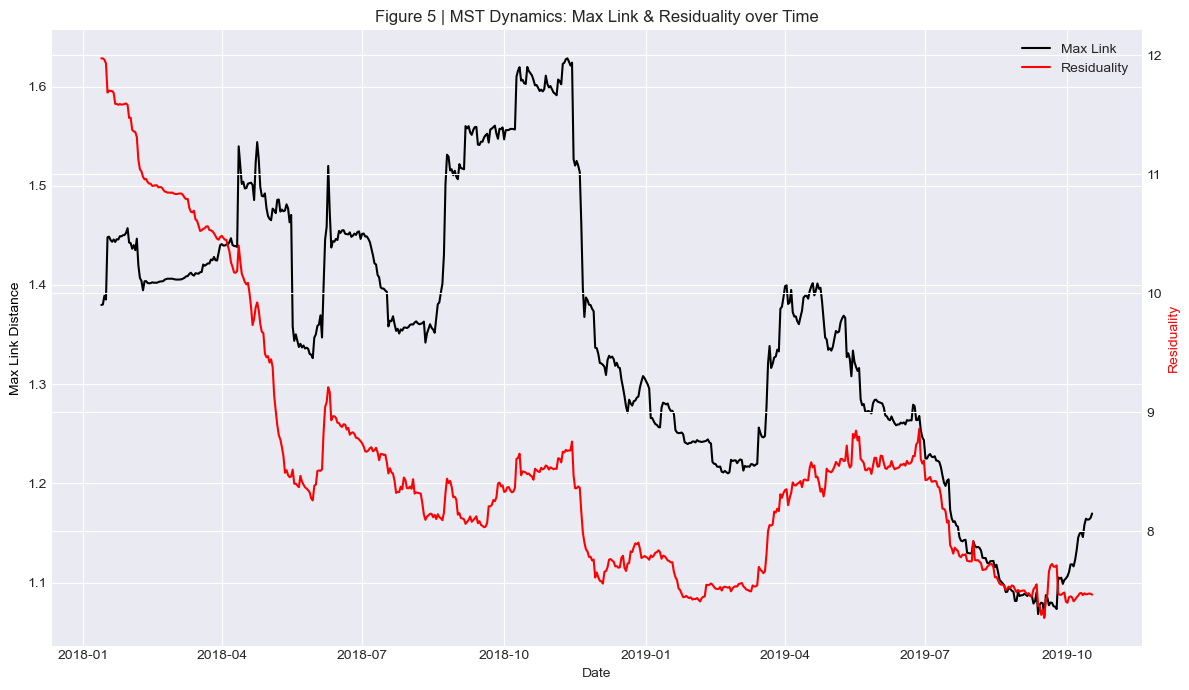

In [7]:
def calculate_rolling_mst_metrics(returns_df, window=120):
    """Hitung dinamika MST dengan rolling window."""
    dates          = returns_df.index[window:]
    max_links      = []
    residualities  = []
    for i in range(window, len(returns_df)):
        window_data = returns_df.iloc[i - window:i]
        corr_f      = apply_rmt_filter(window_data)
        mst_weights = build_mst(corr_f)
        max_links.append(np.max(mst_weights))
        residualities.append(
            np.sum(mst_weights) / (returns_df.shape[1] - 1)
        )
    return pd.DataFrame(
        {'Max Link': max_links, 'Residuality': residualities},
        index=dates
    )

mst_dyn = calculate_rolling_mst_metrics(df_returns)

fig, ax1 = plt.subplots(figsize=(12, 7))
ax1.plot(mst_dyn.index, mst_dyn['Max Link'],
         color='black', label='Max Link')
ax1.set_ylabel('Max Link Distance', color='black')
ax1.set_xlabel('Date')

ax2 = ax1.twinx()
ax2.plot(mst_dyn.index, mst_dyn['Residuality'],
         color='red', label='Residuality')
ax2.set_ylabel('Residuality', color='red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Figure 5 | MST Dynamics: Max Link & Residuality over Time')
plt.tight_layout()
plt.show()

In [8]:
class PortfolioStrategy:
    def __init__(self, name, window_size=120):
        self.name            = name
        self.window_size     = window_size
        self.weights_history = []
        self.returns_history = []
    def get_weights(self, returns_data):
        raise NotImplementedError

class EquallyWeighted(PortfolioStrategy):
    def get_weights(self, returns_data):
        n = returns_data.shape[1]
        return np.ones(n) / n

class ClassicalMarkowitz(PortfolioStrategy):
    """Optimasi Mean-Variance tradisional (minimasi varians portofolio)."""
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        std = returns_data.std()
        valid_assets = std > 1e-12
        if not valid_assets.any(): return np.ones(n_assets) / n_assets
        filtered_data = returns_data.loc[:, valid_assets]
        mu = filtered_data.mean().values
        S  = filtered_data.cov().fillna(0).values
        S  += np.eye(len(mu)) * 1e-8
        objective   = lambda w: w @ S @ w
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(len(mu)) / len(mu),
                       method='SLSQP',
                       bounds=[(0, 1)] * len(mu),
                       constraints=constraints)
        weights = np.zeros(n_assets)
        weights[valid_assets] = res.x if res.success else (np.ones(len(mu)) / len(mu))
        return weights

class GlassoMarkowitz(PortfolioStrategy):
    """Markowitz dengan matriks presisi yang diestimasi via Graphical Lasso."""
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        std = returns_data.std()
        valid_assets = std > 1e-12
        if not valid_assets.any(): return np.ones(n_assets) / n_assets
        filtered_data = returns_data.loc[:, valid_assets]
        mu = filtered_data.mean().values
        try:
            glasso = GraphicalLassoCV()
            glasso.fit(filtered_data.values)
            S = glasso.covariance_
        except Exception:
            S = filtered_data.cov().fillna(0).values
        S += np.eye(len(mu)) * 1e-8
        objective   = lambda w: w @ S @ w
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(len(mu)) / len(mu),
                       method='SLSQP',
                       bounds=[(0, 1)] * len(mu),
                       constraints=constraints)
        weights = np.zeros(n_assets)
        weights[valid_assets] = res.x if res.success else (np.ones(len(mu)) / len(mu))
        return weights

class NetworkMarkowitz(PortfolioStrategy):
    """Network Markowitz: RMT + MST + penalti sentralitas eigenvector."""
    def __init__(self, name="Network Markowitz", gamma=0, window_size=120):
        super().__init__(name, window_size)
        self.gamma = gamma

    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        std = returns_data.std()
        valid_assets = std > 1e-12
        if not valid_assets.any(): return np.ones(n_assets) / n_assets
        filtered_data = returns_data.loc[:, valid_assets]
        mu   = filtered_data.mean().values
        sig  = filtered_data.std().values
        Cf   = apply_rmt_filter(filtered_data)
        dist = build_mst(Cf)
        cent = compute_eigenvector_centrality(dist)
        Sf   = np.outer(sig, sig) * Cf
        Sf += np.eye(len(mu)) * 1e-8
        objective   = lambda w: w @ Sf @ w + self.gamma * np.sum(cent * w)
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(len(mu)) / len(mu),
                       method='SLSQP',
                       bounds=[(0, 1)] * len(mu),
                       constraints=constraints)
        weights = np.zeros(n_assets)
        weights[valid_assets] = res.x if res.success else (np.ones(len(mu)) / len(mu))
        return weights


In [9]:
# BayesianNW class removed - Grid Search is applied statically in the tuning cell


In [10]:

def backtest_strategy(strategy, df_returns,
                      rebalance_freq=7,
                      transaction_cost=0.001,
                      global_start=None):
    """
    Simulasi backtesting dengan rolling window.
    
    Fair comparison: semua strategi mulai dari indeks yang sama (global_start),
    meskipun masing-masing strategi hanya menggunakan data sebesar window_size-nya
    sendiri untuk training.
    """
    window_size  = strategy.window_size
    start_idx    = global_start if global_start is not None else window_size
    portfolio_returns = []
    dates             = []
    
    for i in range(start_idx, len(df_returns), rebalance_freq):
        train_start = max(0, i - window_size)
        train       = df_returns.iloc[train_start:i]
        w           = strategy.get_weights(train)
        test_end    = min(i + rebalance_freq, len(df_returns))
        test_data   = df_returns.iloc[i:test_end]
        for j in range(len(test_data)):
            daily_ret = np.dot(w, test_data.iloc[j].values)
            if j == 0 and len(portfolio_returns) > 0:
                daily_ret -= transaction_cost
            portfolio_returns.append(daily_ret)
            dates.append(test_data.index[j])

    res_df = pd.DataFrame({'date': dates,
                           'return': portfolio_returns})
    res_df['cumulative_return'] = (1 + res_df['return']).cumprod()
    return {
        'strategy':           strategy.name,
        'returns':            np.array(portfolio_returns),
        'cumulative_returns': res_df['cumulative_return'].values,
        'results_df':         res_df
    }

print("Backtest function defined!")

Backtest function defined!


In [11]:
df_tuning = df_returns.copy()  # Use ALL data for in-sample parameter tuning
print(f"Tuning Data: {df_tuning.index[0].date()} to {df_tuning.index[-1].date()}")
print(f"Total Days: {len(df_tuning)}\n")

def objective_base(params, target_metric):
    w_val, g_val = int(params[0]), float(params[1])
    if len(df_tuning) <= w_val + 10:
        return 1e9
    temp_strat = NetworkMarkowitz("Temp", gamma=g_val, window_size=w_val)
    try:
        res = backtest_strategy(temp_strat, df_tuning, global_start=max(120, w_val))
        rets = res['returns']
        if len(rets) < 10:
            return 1e9
        if target_metric == 'VAR':
            return abs(np.percentile(rets, 5))
        elif target_metric == 'SHARPE':
            std = np.std(rets)
            return -(np.mean(rets) / std * np.sqrt(252)) if std > 1e-9 else 1e9
        elif target_metric == 'RACHEV':
            rachev = calculate_rachev_ratio(pd.Series(rets), alpha=0.10)
            return -rachev
    except:
        return 1e9

# ─────────────────────────────────────────────────────────────────────────────
# COARSE-TO-FINE GRID SEARCH  (2-stage)
# Stage 1: Coarse grid   → find promising region   (~96 combinations per metric)
# Stage 2: Fine grid     → zoom in & refine        (~varies per metric)
# Total: ~288 trials vs 7308 in full Grid Search  (≈96% reduction)
# ─────────────────────────────────────────────────────────────────────────────

# --- STAGE 1: Coarse grid ---
COARSE_W_STEP = 5   # every 5 windows:  5, 10, 15, ..., 120  → 24 values
COARSE_G_STEP = 4   # every 4 gammas : 0.0, 0.4, 0.8, 1.2, 1.6, 2.0 → 6 values  (idx 0..20 step 4)
FINE_MARGIN_W = 10  # ± 10 around coarse best window
FINE_MARGIN_G = 3   # ± 3 indices (0.3) around coarse best gamma index

window_coarse = list(range(5, 121, COARSE_W_STEP))
gamma_all     = [round(g * 0.1, 1) for g in range(0, 21)]  # 0.0 .. 2.0 (21 values)
gamma_coarse  = gamma_all[::COARSE_G_STEP]                   # pick every 4th

coarse_combos = len(window_coarse) * len(gamma_coarse)
print(f"Stage 1 – Coarse Grid: {len(window_coarse)} Window x {len(gamma_coarse)} Gamma "
      f"= {coarse_combos} combinations per metric")

results_tuning = {}
for metric in ['VAR', 'SHARPE', 'RACHEV']:
    print(f"\n[Stage 1] Coarse search – {metric}...")
    valid_coarse = []
    for w in window_coarse:
        for g in gamma_coarse:
            score = objective_base([w, g], metric)
            if score < 1e8:
                valid_coarse.append({'W': w, 'G': g, 'score': score})

    if not valid_coarse:
        print(f"  ! No valid coarse result for {metric}, using defaults.")
        results_tuning[metric] = {'W': 20, 'G': 0.5, 'score': 0}
        continue

    best_coarse = min(valid_coarse, key=lambda x: x['score'])
    best_w_c    = best_coarse['W']
    best_g_c    = best_coarse['G']
    print(f"  > Coarse best {metric}: W={best_w_c}, G={best_g_c:.1f}  "
          f"(Score: {abs(best_coarse['score']):.4f})")

    # --- STAGE 2: Fine grid around coarse best ---
    w_lo = max(5,   best_w_c - FINE_MARGIN_W)
    w_hi = min(120, best_w_c + FINE_MARGIN_W)
    window_fine = list(range(w_lo, w_hi + 1))

    g_idx_c   = round(best_g_c / 0.1)               # convert back to index
    gi_lo     = max(0,  g_idx_c - FINE_MARGIN_G)
    gi_hi     = min(20, g_idx_c + FINE_MARGIN_G)
    gamma_fine = [round(i * 0.1, 1) for i in range(gi_lo, gi_hi + 1)]

    fine_combos = len(window_fine) * len(gamma_fine)
    print(f"[Stage 2] Fine search – {metric}: "
          f"W=[{w_lo}..{w_hi}] x G=[{gamma_fine[0]}..{gamma_fine[-1]}] "
          f"= {fine_combos} combinations")

    valid_fine = []
    for w in window_fine:
        for g in gamma_fine:
            score = objective_base([w, g], metric)
            if score < 1e8:
                valid_fine.append({'W': w, 'G': g, 'score': score})

    if valid_fine:
        best_fine = min(valid_fine, key=lambda x: x['score'])
        results_tuning[metric] = {
            'W': int(best_fine['W']),
            'G': float(best_fine['G']),
            'score': abs(best_fine['score'])
        }
        print(f"  > Fine best {metric}: W={best_fine['W']}, G={best_fine['G']:.1f}  "
              f"(Score: {abs(best_fine['score']):.4f})")
    else:
        results_tuning[metric] = {
            'W': int(best_coarse['W']),
            'G': float(best_coarse['G']),
            'score': abs(best_coarse['score'])
        }
        print(f"  ! No better fine result found, keeping coarse best.")

tuned_params = results_tuning
total_trials = (coarse_combos + sum(
    (min(120, results_tuning[m]['W'] + FINE_MARGIN_W) - max(5, results_tuning[m]['W'] - FINE_MARGIN_W) + 1) *
    (min(20, round(results_tuning[m]['G']/0.1) + FINE_MARGIN_G) - max(0, round(results_tuning[m]['G']/0.1) - FINE_MARGIN_G) + 1)
    for m in results_tuning
)) * 3  # rough estimate
print(f"\nCoarse-to-Fine Grid Search tuning complete.")
print(f"Results: { {m: f"W={p['W']}, G={p['G']:.1f}" for m, p in tuned_params.items()} }")


Tuning Data: 2017-09-15 to 2019-10-17
Total Days: 763

Stage 1 – Coarse Grid: 24 Window x 6 Gamma = 144 combinations per metric

[Stage 1] Coarse search – VAR...
  > Coarse best VAR: W=25, G=0.4  (Score: 0.0214)
[Stage 2] Fine search – VAR: W=[15..35] x G=[0.1..0.7] = 147 combinations
  > Fine best VAR: W=33, G=0.7  (Score: 0.0201)

[Stage 1] Coarse search – SHARPE...
  > Coarse best SHARPE: W=25, G=0.4  (Score: 0.5109)
[Stage 2] Fine search – SHARPE: W=[15..35] x G=[0.1..0.7] = 147 combinations
  > Fine best SHARPE: W=25, G=0.4  (Score: 0.5109)

[Stage 1] Coarse search – RACHEV...
  > Coarse best RACHEV: W=25, G=0.4  (Score: 1.2526)
[Stage 2] Fine search – RACHEV: W=[15..35] x G=[0.1..0.7] = 147 combinations
  > Fine best RACHEV: W=25, G=0.4  (Score: 1.2526)

Coarse-to-Fine Grid Search tuning complete.
Results: {'VAR': 'W=33, G=0.7', 'SHARPE': 'W=25, G=0.4', 'RACHEV': 'W=25, G=0.4'}


In [12]:
strategies = [
    EquallyWeighted("EW"),
    ClassicalMarkowitz("CM"),
    GlassoMarkowitz("GM"),
    NetworkMarkowitz("NW (gamma=0)", gamma=0),
    NetworkMarkowitz("NW (gamma=1.0)", gamma=1.0),
    
    NetworkMarkowitz(f"NW Tuned (VAR: W={tuned_params['VAR']['W']}, G={tuned_params['VAR']['G']:.2f})", 
                     gamma=tuned_params['VAR']['G'], window_size=tuned_params['VAR']['W']),
                     
    NetworkMarkowitz(f"NW Tuned (Sharpe: W={tuned_params['SHARPE']['W']}, G={tuned_params['SHARPE']['G']:.2f})", 
                     gamma=tuned_params['SHARPE']['G'], window_size=tuned_params['SHARPE']['W']),
                     
    NetworkMarkowitz(f"NW Tuned (Rachev: W={tuned_params['RACHEV']['W']}, G={tuned_params['RACHEV']['G']:.2f})", 
                     gamma=tuned_params['RACHEV']['G'], window_size=tuned_params['RACHEV']['W']),
]

MAX_WINDOW   = max(s.window_size for s in strategies)
global_start = MAX_WINDOW

results = {}
for strat in strategies:
    print(f"Running: {strat.name}...")
    results[strat.name] = backtest_strategy(strat, df_returns, global_start=global_start)

print("\nAll backtests completed!")

Running: EW...
Running: CM...
Running: GM...
Running: NW (gamma=0)...
Running: NW (gamma=1.0)...
Running: NW Tuned (VAR: W=33, G=0.70)...
Running: NW Tuned (Sharpe: W=25, G=0.40)...
Running: NW Tuned (Rachev: W=25, G=0.40)...

All backtests completed!


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

def show_bayesian_results(strat_name):
    strat = next((s for s in strategies if s.name == strat_name), None)
    if not strat or not strat.param_history:
        print(f"Data untuk {strat_name} tidak ditemukan atau backtest belum dijalankan.")
        return
    
    df = pd.DataFrame(strat.param_history)
    print(f"\n{'='*50}\nParameter Optimal: {strat_name}\n{'='*50}")
    print(df.tail(10).to_string(index=False))
    
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax2 = ax1.twinx()
    ax1.plot(df['date'], df['window'], 'g-', label='Window Size')
    ax2.plot(df['date'], df['gamma'], 'b-', label='Gamma (Penalty)')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Window', color='g')
    ax2.set_ylabel('Gamma', color='b')
    plt.title(f'Evolusi Parameter Adaptive {strat_name}')
    plt.show()

show_bayesian_results('NW Bayesian (VAR)')
show_bayesian_results('NW Bayesian (Sharpe)')


Data untuk NW Bayesian (VAR) tidak ditemukan atau backtest belum dijalankan.
Data untuk NW Bayesian (Sharpe) tidak ditemukan atau backtest belum dijalankan.


In [14]:
target_dates = [
    '2018-01-31', '2018-05-31', '2018-09-30',
    '2019-01-31', '2019-05-31', '2019-09-30'
]

table2_rows = []
for strat in strategies:
    strat_name = strat.name
    if strat_name not in results: continue
    
    res = results[strat_name]
    df_res = res['results_df'].set_index('date')
    row    = {'Strategy': strat_name}
    
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_w = np.mean([p['window'] for p in strat.param_history])
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w = strat.window_size
        avg_g = strat.gamma
    else:
        avg_w = getattr(strat, 'window_size', '-')
        avg_g = '-'
        
    row['Window'] = f"{avg_w:.0f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['Gamma'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g

    for td in target_dates:
        idx     = df_res.index.searchsorted(pd.Timestamp(td))
        idx     = min(idx, len(df_res) - 1)
        cum_ret = (df_res['cumulative_return'].iloc[idx] - 1) * 100
        row[td] = round(cum_ret, 2)
    table2_rows.append(row)

table2 = pd.DataFrame(table2_rows).set_index('Strategy')
table2.rename(columns={
    '2018-01-31': 'Jan-2018', '2018-05-31': 'May-2018', '2018-09-30': 'Sep-2018',
    '2019-01-31': 'Jan-2019', '2019-05-31': 'May-2019', '2019-09-30': 'Sep-2019'
}, inplace=True)

print("TABLE 2 | Cumulative Profits and Losses (%) with Parameters")
display(table2)

TABLE 2 | Cumulative Profits and Losses (%) with Parameters


,Window,Gamma,Jan-2018,May-2018,Sep-2018,Jan-2019,May-2019,Sep-2019
Strategy,,,,,,,,
EW,120,-,-35.53,-58.96,-77.02,-89.67,-77.88,-88.82
CM,120,-,-34.32,-57.88,-59.66,-68.22,-55.67,-62.16
GM,120,-,-33.86,-60.11,-61.90,-73.12,-62.49,-67.53
NW (gamma=0),120,0.00,-41.59,-62.30,-63.81,-71.79,-61.83,-68.05
NW (gamma=1.0),120,1.00,-39.09,-51.94,-53.57,-54.17,-41.10,-48.05
"NW Tuned (VAR: W=33, G=0.70)",33,0.70,-29.30,-37.39,-40.22,-39.03,5.68,2.36
"NW Tuned (Sharpe: W=25, G=0.40)",25,0.40,-20.17,-26.99,-29.97,-28.32,39.78,32.74
"NW Tuned (Rachev: W=25, G=0.40)",25,0.40,-20.17,-26.99,-29.97,-28.32,39.78,32.74


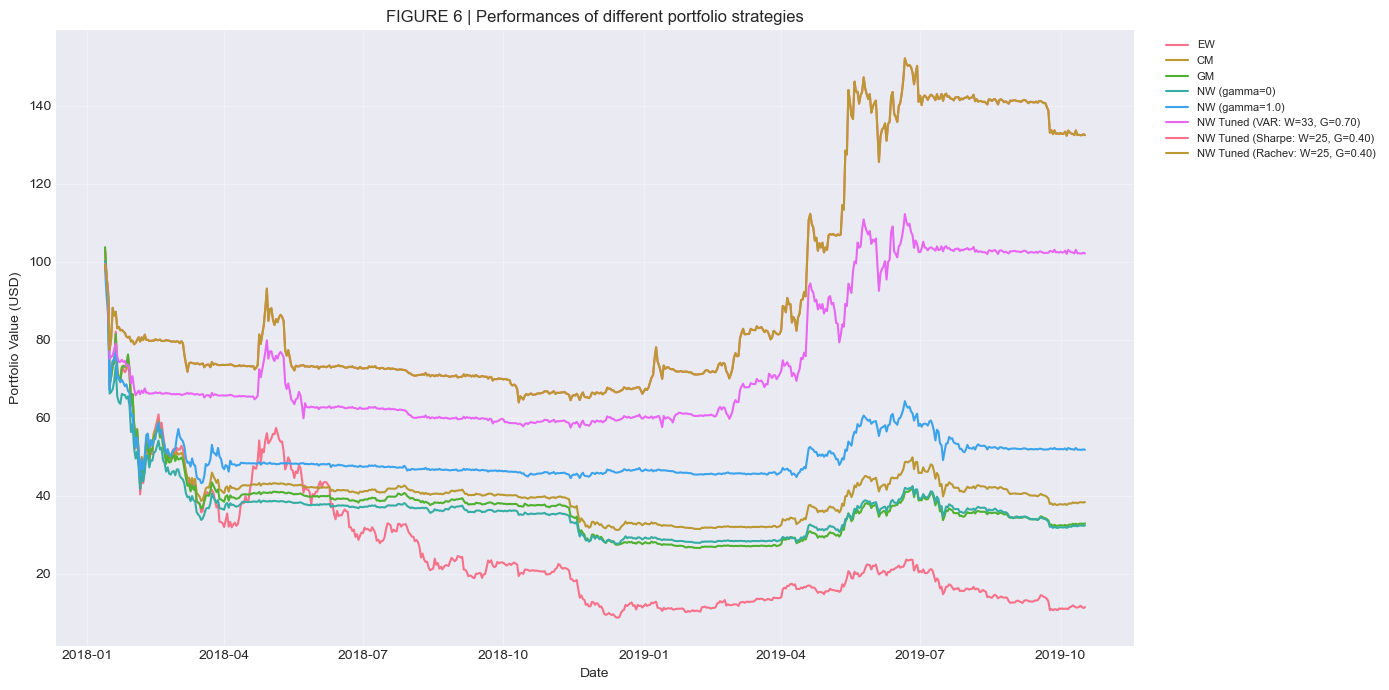

In [15]:
plt.figure(figsize=(14, 7))
for name, res in results.items():
    plt.plot(res['results_df']['date'],
             res['cumulative_returns'] * 100,
             label=name)
plt.title('FIGURE 6 | Performances of different portfolio strategies')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (USD)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
period_ranges = [
    ('Jan-2018', '2017-10-01', '2018-01-31'),
    ('May-2018', '2018-02-01', '2018-05-31'),
    ('Sep-2018', '2018-06-01', '2018-09-30'),
    ('Jan-2019', '2018-10-01', '2019-01-31'),
    ('May-2019', '2019-02-01', '2019-05-31'),
    ('Sep-2019', '2019-06-01', '2019-09-30'),
]

table3_rows = []
for strat in strategies:
    strat_name = strat.name
    if strat_name not in results: continue
    res = results[strat_name]
    df_res = res['results_df'].set_index('date')
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_w = np.mean([p['window'] for p in strat.param_history])
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_w = getattr(strat, 'window_size', '-')
        avg_g = getattr(strat, 'gamma', '-')
    row    = {'Strategy': strat_name}
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_g = getattr(strat, 'gamma', '-')
    
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_g = getattr(strat, 'gamma', '-')
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    for period_label, start, end in period_ranges:
        segment = df_res.loc[start:end, 'return'].values
        if len(segment) > 0:
            v = abs(calculate_var(segment, 0.95)) * 100
        else:
            v = np.nan
        row[period_label] = round(v, 4)
    table3_rows.append(row)

table3 = pd.DataFrame(table3_rows).set_index('Strategy')
print("TABLE 3 | VaR 95% (4-month window, scaled x100)")
display(table3)

TABLE 3 | VaR 95% (4-month window, scaled x100)


,W,G,Jan-2018,May-2018,Sep-2018,Jan-2019,May-2019,Sep-2019
Strategy,,,,,,,,
EW,120.0,-,13.7904,9.5511,6.5477,9.4876,3.6840,8.2085
CM,120.0,-,12.8261,5.8008,0.9993,1.7255,1.7011,3.8309
GM,120.0,-,13.4648,5.9287,1.1856,2.4277,1.8379,4.2622
NW (gamma=0),120.0,0.00,12.4709,5.6166,1.1500,1.8397,1.5141,4.0012
NW (gamma=1.0),120.0,1.00,10.3486,5.6183,0.7120,0.9561,1.2827,3.0550
"NW Tuned (VAR: W=33, G=0.70)",33.0,0.70,6.5951,2.8816,0.7667,1.1674,2.4558,1.8905
"NW Tuned (Sharpe: W=25, G=0.40)",25.0,0.40,6.3113,2.8039,0.6978,1.5677,2.4755,2.0084
"NW Tuned (Rachev: W=25, G=0.40)",25.0,0.40,6.3113,2.8039,0.6978,1.5677,2.4755,2.0084


In [17]:
table4_rows = []
for strat in strategies:
    strat_name = strat.name
    if strat_name not in results: continue
    res = results[strat_name]
    df_res = res['results_df'].set_index('date')
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_w = np.mean([p['window'] for p in strat.param_history])
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_w = getattr(strat, 'window_size', '-')
        avg_g = getattr(strat, 'gamma', '-')
    row    = {'Strategy': strat_name}
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_g = getattr(strat, 'gamma', '-')
    
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_g = getattr(strat, 'gamma', '-')
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    for period_label, start, end in period_ranges:
        segment = df_res.loc[start:end, 'return'].values
        if len(segment) > 1 and np.std(segment) > 1e-6:
            sr = np.mean(segment) / np.std(segment)
        else:
            sr = np.nan
        row[period_label] = round(sr, 4)
    table4_rows.append(row)

table4 = pd.DataFrame(table4_rows).set_index('Strategy')
print("TABLE 4 | Sharpe Ratio (4-month window)")
display(table4)

TABLE 4 | Sharpe Ratio (4-month window)


,W,G,Jan-2018,May-2018,Sep-2018,Jan-2019,May-2019,Sep-2019
Strategy,,,,,,,,
EW,120.0,-,-0.2532,-0.0425,-0.0986,-0.1270,0.2016,-0.1298
CM,120.0,-,-0.2508,-0.0984,-0.0577,-0.1500,0.1904,-0.0598
GM,120.0,-,-0.2355,-0.1032,-0.0537,-0.1873,0.1775,-0.0526
NW (gamma=0),120.0,0.00,-0.3442,-0.1053,-0.0523,-0.1514,0.1851,-0.0694
NW (gamma=1.0),120.0,1.00,-0.3849,-0.0450,-0.0632,-0.0152,0.1567,-0.0498
"NW Tuned (VAR: W=33, G=0.70)",33.0,0.70,-0.3728,-0.0415,-0.0913,0.0233,0.1998,-0.0080
"NW Tuned (Sharpe: W=25, G=0.40)",25.0,0.40,-0.2384,-0.0270,-0.0923,0.0211,0.2091,-0.0204
"NW Tuned (Rachev: W=25, G=0.40)",25.0,0.40,-0.2384,-0.0270,-0.0923,0.0211,0.2091,-0.0204


In [18]:
table5_rows = []
for strat in strategies:
    strat_name = strat.name
    if strat_name not in results: continue
    res = results[strat_name]
    df_res = res['results_df'].set_index('date')
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_w = np.mean([p['window'] for p in strat.param_history])
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_w = getattr(strat, 'window_size', '-')
        avg_g = getattr(strat, 'gamma', '-')
    row    = {'Strategy': strat_name}
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_g = getattr(strat, 'gamma', '-')
    
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_g = getattr(strat, 'gamma', '-')
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    for period_label, start, end in period_ranges:
        segment = df_res.loc[start:end, 'return'].values
        if len(segment) > 5:
            rr = calculate_rachev_ratio(segment, alpha=0.10)
        else:
            rr = np.nan
        row[period_label] = round(rr, 4)
    table5_rows.append(row)

table5 = pd.DataFrame(table5_rows).set_index('Strategy')
print("TABLE 5 | Rachev Ratio (alpha=10%, 4-month window)")
display(table5)

TABLE 5 | Rachev Ratio (alpha=10%, 4-month window)


,W,G,Jan-2018,May-2018,Sep-2018,Jan-2019,May-2019,Sep-2019
Strategy,,,,,,,,
EW,120.0,-,0.3926,0.8889,0.8062,0.7200,1.7430,0.5381
CM,120.0,-,0.3969,0.7612,0.7865,0.6506,2.0115,0.7510
GM,120.0,-,0.4126,0.7515,0.7760,0.5600,1.6893,0.7353
NW (gamma=0),120.0,0.00,0.2494,0.7591,0.7824,0.6389,2.1048,0.7820
NW (gamma=1.0),120.0,1.00,0.3488,1.0222,0.8170,1.0171,2.1687,0.8614
"NW Tuned (VAR: W=33, G=0.70)",33.0,0.70,0.1967,0.9248,0.7264,1.1274,2.0829,0.9205
"NW Tuned (Sharpe: W=25, G=0.40)",25.0,0.40,0.6665,0.9812,0.8025,1.1438,2.6708,0.8565
"NW Tuned (Rachev: W=25, G=0.40)",25.0,0.40,0.6665,0.9812,0.8025,1.1438,2.6708,0.8565


In [19]:
fase_pasar = {
    'Bearish':  ('2018-01-01', '2019-03-31'),
    'Recovery': ('2019-04-01', '2019-06-30'),
    'Stable':   ('2019-07-01', '2019-10-17')
}

sharpe_rows = []
rachev_rows = []
for strat in strategies:
    strat_name = strat.name
    if strat_name not in results: continue
    res = results[strat_name]
    df_res = res['results_df'].set_index('date')
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_w = np.mean([p['window'] for p in strat.param_history])
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_w = getattr(strat, 'window_size', '-')
        avg_g = getattr(strat, 'gamma', '-')
    sr_row = {'Strategy': strat_name}
    sr_row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    sr_row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_g = getattr(strat, 'gamma', '-')
    
    sr_row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    sr_row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    rr_row = {'Strategy': strat_name}
    rr_row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    rr_row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    rr_row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    rr_row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    for fase, (start, end) in fase_pasar.items():
        segment = df_res.loc[start:end, 'return'].values
        if len(segment) > 1 and np.std(segment) > 1e-6:
            sr = np.mean(segment) / np.std(segment)
        else:
            sr = np.nan
        sr_row[fase] = round(sr, 4)
        if len(segment) > 5:
            rr = calculate_rachev_ratio(segment, alpha=0.10)
        else:
            rr = np.nan
        rr_row[fase] = round(rr, 4)
    sharpe_rows.append(sr_row)
    rachev_rows.append(rr_row)

table6_sharpe = pd.DataFrame(sharpe_rows).set_index('Strategy')
table6_rachev = pd.DataFrame(rachev_rows).set_index('Strategy')

print("TABLE 6 | Market Phase Performance")
print("\nPanel A: Sharpe Ratio")
display(table6_sharpe)
print("\nPanel B: Rachev Ratio (alpha=10%)")
display(table6_rachev)

TABLE 6 | Market Phase Performance

Panel A: Sharpe Ratio


,W,G,Bearish,Recovery,Stable
Strategy,,,,,
EW,120.0,-,-0.0726,0.1286,-0.1301
CM,120.0,-,-0.0923,0.1844,-0.1022
GM,120.0,-,-0.0991,0.1732,-0.0950
NW (gamma=0),120.0,0.00,-0.1072,0.1763,-0.1095
NW (gamma=1.0),120.0,1.00,-0.0685,0.1359,-0.0628
"NW Tuned (VAR: W=33, G=0.70)",33.0,0.70,-0.0399,0.1411,-0.0048
"NW Tuned (Sharpe: W=25, G=0.40)",25.0,0.40,-0.0195,0.1892,-0.0877
"NW Tuned (Rachev: W=25, G=0.40)",25.0,0.40,-0.0195,0.1892,-0.0877



Panel B: Rachev Ratio (alpha=10%)


,W,G,Bearish,Recovery,Stable
Strategy,,,,,
EW,120.0,-,0.7933,1.2168,0.5712
CM,120.0,-,0.6463,1.2463,0.7523
GM,120.0,-,0.6275,1.1627,0.7477
NW (gamma=0),120.0,0.00,0.5982,1.2883,0.7615
NW (gamma=1.0),120.0,1.00,0.7244,1.4069,0.8656
"NW Tuned (VAR: W=33, G=0.70)",33.0,0.70,0.8384,1.4920,1.1048
"NW Tuned (Sharpe: W=25, G=0.40)",25.0,0.40,0.9835,1.9271,0.7771
"NW Tuned (Rachev: W=25, G=0.40)",25.0,0.40,0.9835,1.9271,0.7771


In [20]:
# Bayesian parameter evolution plot removed (not applicable for static Grid Search tuning)


In [21]:
# Bayesian parameter summary removed (not applicable for static Grid Search tuning)
print("Grid Search Tuned Parameters:")
for metric, params in tuned_params.items():
    print(f"  {metric}: W={params['W']}, G={params['G']:.1f}")


Grid Search Tuned Parameters:
  VAR: W=33, G=0.7
  SHARPE: W=25, G=0.4
  RACHEV: W=25, G=0.4


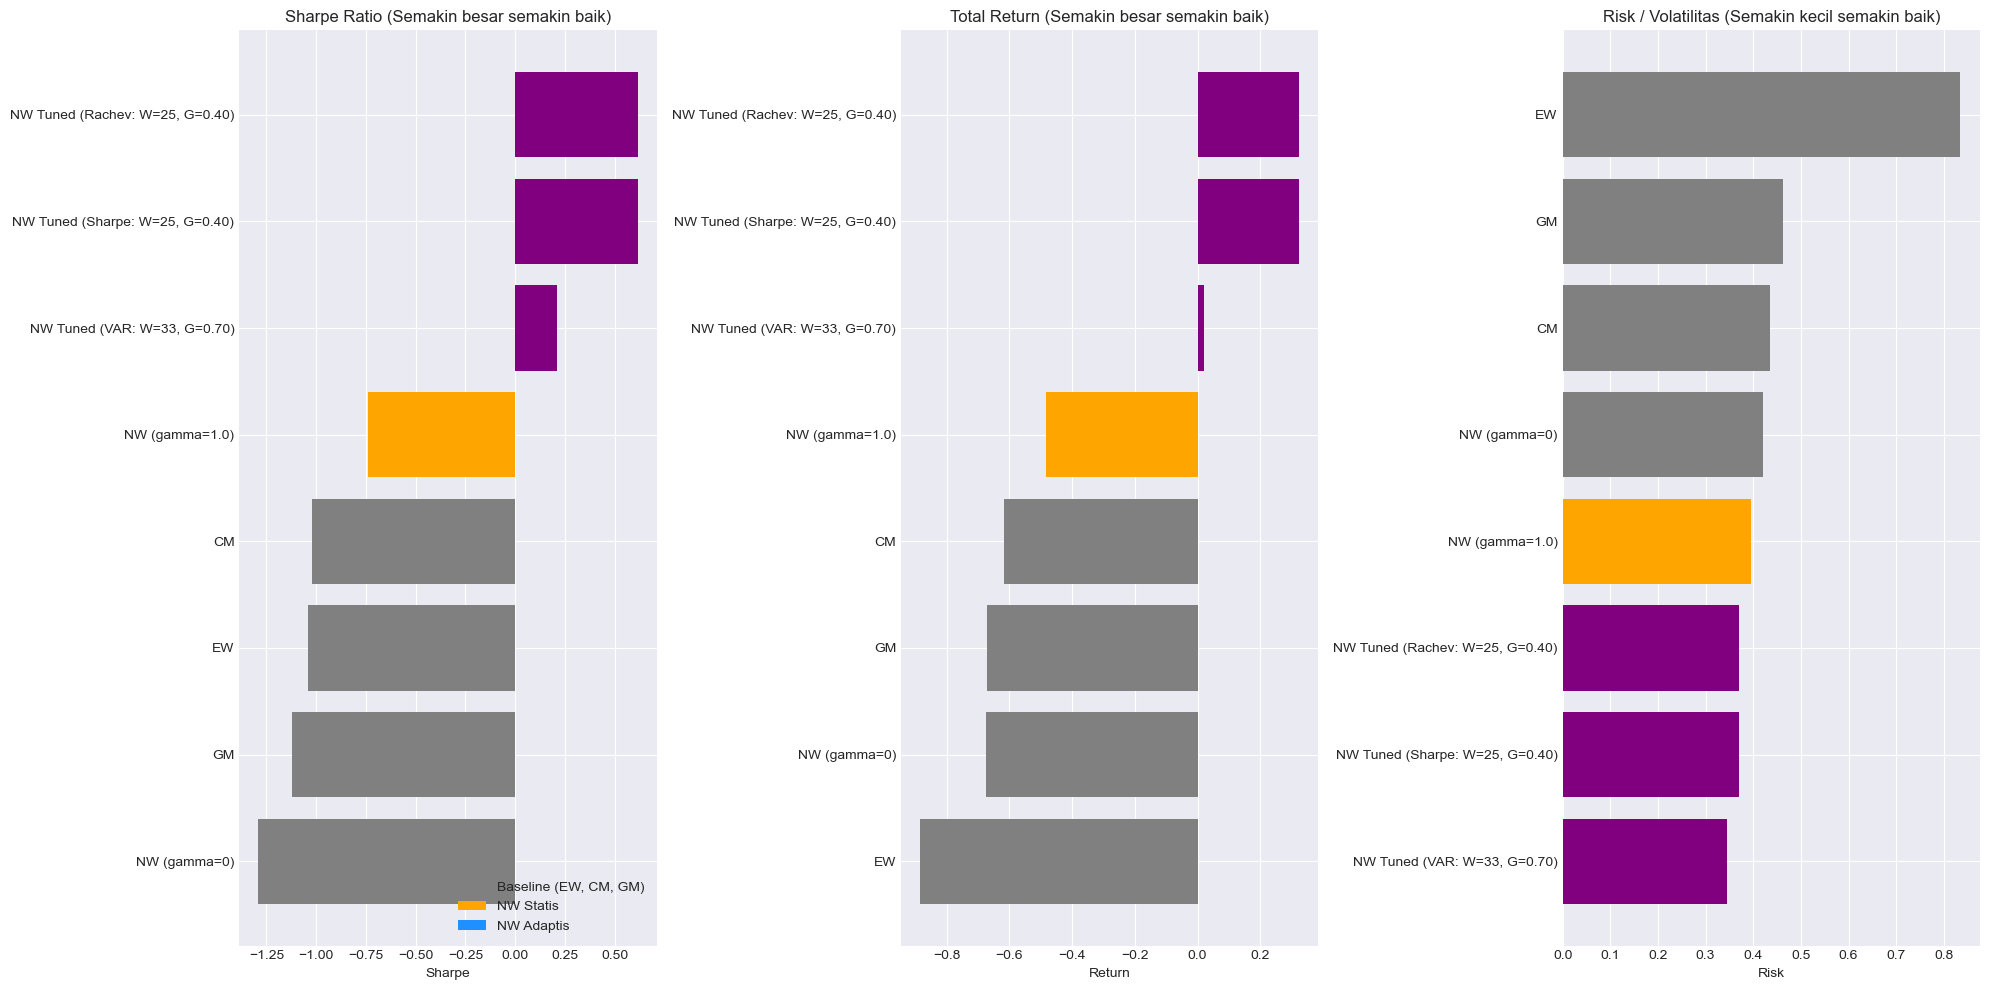

In [22]:
import numpy as np

data_rows = []
for strat_name, res in results.items():
    df_res = res['results_df']
    returns = df_res['return'].dropna().values
    
    if len(returns) > 0:
        tot_ret = np.prod(1 + returns) - 1 # or np.sum(returns) if log returns
        risk = np.std(returns) * np.sqrt(365) # annualized volatility
        sharpe = (np.mean(returns) / np.std(returns)) * np.sqrt(365) if np.std(returns) > 1e-6 else 0
    else:
        tot_ret, risk, sharpe = 0, 0, 0
        
    data_rows.append({'Strategy': strat_name, 'Return': tot_ret, 'Risk': risk, 'Sharpe': sharpe})

comparison = pd.DataFrame(data_rows).set_index('Strategy')

def get_color(strategy_name):
    if strategy_name in ['EW', 'CM', 'CM 30', 'GM'] or 'Static' not in strategy_name and 'gamma=0' in strategy_name:
        return 'gray'
    elif 'NW Static' in strategy_name or '(gamma' in strategy_name:
        return 'orange' # Static NW
    elif 'Adaptis' in strategy_name or 'GS' in strategy_name:
        return 'dodgerblue' # Adaptive NW
    else:
        return 'purple'

colors = [get_color(idx) for idx in comparison.index]

fig, axes = plt.subplots(1, 3, figsize=(20, 10))

df_sharpe = comparison['Sharpe'].sort_values(ascending=True)
c_sharpe = [get_color(idx) for idx in df_sharpe.index]
axes[0].barh(df_sharpe.index, df_sharpe.values, color=c_sharpe)
axes[0].set_title('Sharpe Ratio (Semakin besar semakin baik)')
axes[0].set_xlabel('Sharpe')

df_return = comparison['Return'].sort_values(ascending=True)
c_return = [get_color(idx) for idx in df_return.index]
axes[1].barh(df_return.index, df_return.values, color=c_return)
axes[1].set_title('Total Return (Semakin besar semakin baik)')
axes[1].set_xlabel('Return')

df_risk = comparison['Risk'].sort_values(ascending=True)
c_risk = [get_color(idx) for idx in df_risk.index]
axes[2].barh(df_risk.index, df_risk.values, color=c_risk)
axes[2].set_title('Risk / Volatilitas (Semakin kecil semakin baik)')
axes[2].set_xlabel('Risk')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='gray', label='Baseline (EW, CM, GM)'),
                   Patch(facecolor='orange', label='NW Statis'),
                   Patch(facecolor='dodgerblue', label='NW Adaptis')]
axes[0].legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

fig.savefig('horizontal_bar_comparison.png', dpi=300, bbox_inches='tight')
